# Inference Sensitivity in the Scattered-Voltage Basis $V_\mathrm{sca}$

Companion to `inference_sensitivity.ipynb` for the formulation of `VscatBound.ipynb`, where the optimization variable is the
scattered voltage $x = V_\mathrm{sca} = -Z_0 I$ and the current is recovered as $I = -W x$, $W = Z_0^{-1}$
(all quantities in the Cholesky-whitened basis, $Z_\rho = Z_\mathrm{s}\mathbf 1$).

The material density is inferred from the total voltage,
$$
\rho_i = \frac{Z_\mathrm{s} I_i}{V_i + V_{\mathrm{sca},i}}, \qquad I = -W V_\mathrm{sca}.
$$
On material $V + V_\mathrm{sca} = Z_\mathrm{s} I$, which is small ($|Z_\mathrm{s}| \ll \|Z_0\|$): the denominator is the difference of
two quantities of order $\|V_\mathrm{sca}\|$. A relative error $\eta$ in $V_\mathrm{sca}$ is therefore amplified in the denominator by
$$
\kappa_V = \frac{\|V_\mathrm{sca}\|}{\|V + V_\mathrm{sca}\|} \approx \frac{\|Z_0 I\|}{|Z_\mathrm{s}|\,\|I\|} \le \frac{\|Z_0\|_2}{|Z_\mathrm{s}|},
$$
the same mechanism as in the current basis, while the numerator $I = -W V_\mathrm{sca}$ additionally picks up the conditioning of $Z_0$.
This notebook measures

1. $\kappa_V$ against the conductivity reduction $s = \sigma/\sigma_\mathrm{Cu}$,
2. the density error against a relative perturbation of $V_\mathrm{sca}$, compared with the same perturbation of $I$,
3. support recovery of a known binary structure by the density fit, the pointwise current fit, the branch test and group-wise fits,
4. the fits evaluated at the actual dual solution of `VscatBound.ipynb`.

In [1]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

np.random.seed(0)
np.seterr(all='ignore')

epsilon_0 = 8.854e-12
mu_0 = 4e-7 * np.pi
frequency = 2.45e9
omega = 2 * np.pi * frequency
sigma_Cu = 5.96e7
E0 = 1e3

Lmat = np.loadtxt("Lmat_dipole.txt", delimiter=',')
R0raw = np.loadtxt("R0_dipole.txt", delimiter=',')
X0raw = np.loadtxt("X0_dipole.txt", delimiter=',')
Vraw = E0 * np.loadtxt("V_dipole.txt", delimiter=',')
Ndes = Lmat.shape[0]

Lchol = np.linalg.cholesky(Lmat).conj().T
LcholInv = np.linalg.inv(Lchol)

def Msym(M):
    return 0.5 * (M.conj().T + M)

def Mchol(M):
    return Msym(LcholInv.conj().T @ M @ LcholInv)

R0 = Mchol(R0raw)
X0 = Mchol(X0raw)
Z0 = R0 + 1j * X0
Vinc = (LcholInv.conj().T @ Vraw).astype(complex)
W = np.linalg.inv(Z0)
print(f"N = {Ndes}, cond(Z0) = {np.linalg.cond(Z0):.3e}, ||Z0||_2 = {np.linalg.norm(Z0, 2):.3e}")

N = 195, cond(Z0) = 1.750e+04, ||Z0||_2 = 2.084e+04


## Helper functions

`surface_impedance(s)` gives $Z_\mathrm{s}$ for conductivity $s\,\sigma_\mathrm{Cu}$. `structure(rho, Zs)` solves the physical problem
$(Z_\mathrm{s} + \operatorname{diag}(\rho) Z_0)\, I = \operatorname{diag}(\rho) V$ and returns $(I, V_\mathrm{sca})$; for $\rho = \mathbf 1$ it is the full plate.
The fits take $V_\mathrm{sca}$ and use $b_i = (V_i + V_{\mathrm{sca},i})/Z_\mathrm{s}$, $I = -W V_\mathrm{sca}$:

* density fit: $\operatorname{clip}_{[0,1]}\operatorname{Re}\rho_i$,
* pointwise current fit: $\operatorname{clip}_{[0,1]}\operatorname{Re}(b_i^* I_i)/|b_i|^2$ (as in `VscatBound.ipynb`),
* branch test: $\rho_i = 1 \iff |I_i - b_i| < |I_i|$,
* group-wise versions with one density per group (uniform resp. $|b_i|^2$-weighted average).

In [2]:
def surface_impedance(s):
    sigma = s * sigma_Cu
    delta = np.sqrt(2 / (omega * mu_0 * sigma))
    return (1 + 1j) / (sigma * delta)


def structure(rho, Zs):
    S = np.diag(rho.astype(complex))
    I = np.linalg.solve(Zs * np.eye(Ndes) + S @ Z0, S @ Vinc)
    return I, -Z0 @ I


def VtoI(Vsca):
    return -W @ Vsca


def complex_density(Vsca, Zs):
    return Zs * VtoI(Vsca) / (Vinc + Vsca)


def fit_inputs(Vsca, Zs):
    return VtoI(Vsca), (Vinc + Vsca) / Zs


def fit_density(Vsca, Zs, groups=None):
    r = np.real(complex_density(Vsca, Zs))
    if groups is None:
        return np.clip(r, 0, 1)
    out = np.empty(Ndes)
    for g in groups:
        out[g] = np.clip(np.mean(r[g]), 0, 1)
    return out


def fit_current(Vsca, Zs, groups=None):
    I, b = fit_inputs(Vsca, Zs)
    num, den = np.real(np.conj(b) * I), np.abs(b) ** 2
    if groups is None:
        return np.clip(num / den, 0, 1)
    out = np.empty(Ndes)
    for g in groups:
        out[g] = np.clip(num[g].sum() / den[g].sum(), 0, 1)
    return out


def branch_test(Vsca, Zs):
    I, b = fit_inputs(Vsca, Zs)
    return np.abs(I - b) < np.abs(I)


def perturb(x, eta):
    n = np.random.randn(len(x)) + 1j * np.random.randn(len(x))
    return x + eta * np.linalg.norm(x) / np.linalg.norm(n) * n


Zs_Cu = surface_impedance(1.0)
Ifull, Vfull = structure(np.ones(Ndes), Zs_Cu)
print(f"Zs (copper) = {Zs_Cu:.3e}")
print(f"full plate: max|rho - 1| = {np.max(np.abs(complex_density(Vfull, Zs_Cu) - 1)):.2e}")

Zs (copper) = 1.274e-02+1.274e-02j
full plate: max|rho - 1| = 1.45e-09


## 1. Amplification factor vs. conductivity reduction

Measured $\kappa_V = \|V_\mathrm{sca}\|/\|V + V_\mathrm{sca}\|$ on the full plate, compared with the operator bound
$\|Z_0\|_2/|Z_\mathrm{s}|$ (the $\kappa$ of the current basis).

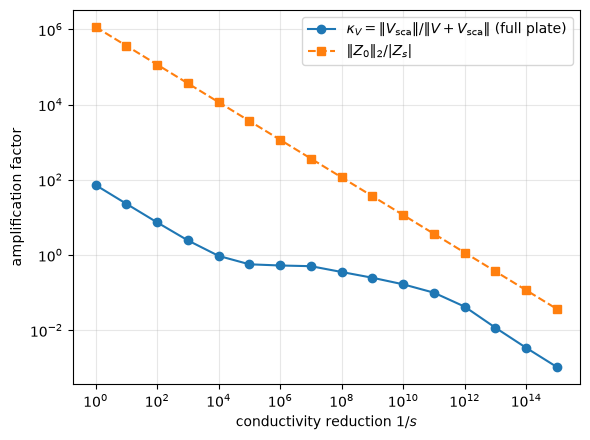

s = 1e+00   kappa_V = 7.227e+01   ||Z0||/|Zs| = 1.157e+06
s = 1e-03   kappa_V = 2.438e+00   ||Z0||/|Zs| = 3.658e+04
s = 1e-06   kappa_V = 5.256e-01   ||Z0||/|Zs| = 1.157e+03
s = 1e-09   kappa_V = 2.481e-01   ||Z0||/|Zs| = 3.658e+01
s = 1e-12   kappa_V = 4.224e-02   ||Z0||/|Zs| = 1.157e+00
s = 1e-15   kappa_V = 1.047e-03   ||Z0||/|Zs| = 3.658e-02


In [3]:
s_values = np.logspace(0, -15, 16)
kV, kOp = [], []
for s in s_values:
    Zs = surface_impedance(s)
    _, Vs = structure(np.ones(Ndes), Zs)
    kV.append(np.linalg.norm(Vs) / np.linalg.norm(Vinc + Vs))
    kOp.append(np.linalg.norm(Z0, 2) / abs(Zs))
kV, kOp = np.array(kV), np.array(kOp)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.loglog(1 / s_values, kV, 'o-', label=r'$\kappa_V = \|V_\mathrm{sca}\|/\|V+V_\mathrm{sca}\|$ (full plate)')
ax.loglog(1 / s_values, kOp, 's--', label=r'$\|Z_0\|_2/|Z_s|$')
ax.set_xlabel(r'conductivity reduction $1/s$')
ax.set_ylabel('amplification factor')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()

for s, a, b in zip(s_values[::3], kV[::3], kOp[::3]):
    print(f"s = {s:.0e}   kappa_V = {a:.3e}   ||Z0||/|Zs| = {b:.3e}")

## 2. Density error vs. perturbation: $V_\mathrm{sca}$ basis vs. $I$ basis

For each $s$ the exact full-plate solution is perturbed by relative noise $\eta$, once in $V_\mathrm{sca}$ (the variable of
`VscatBound.ipynb`) and once in $I$ (the variable of the current-basis bound, with $V_\mathrm{sca} = -Z_0 I$ recomputed).
The error is $\max_i|\rho_i - 1|$ of the complex density.

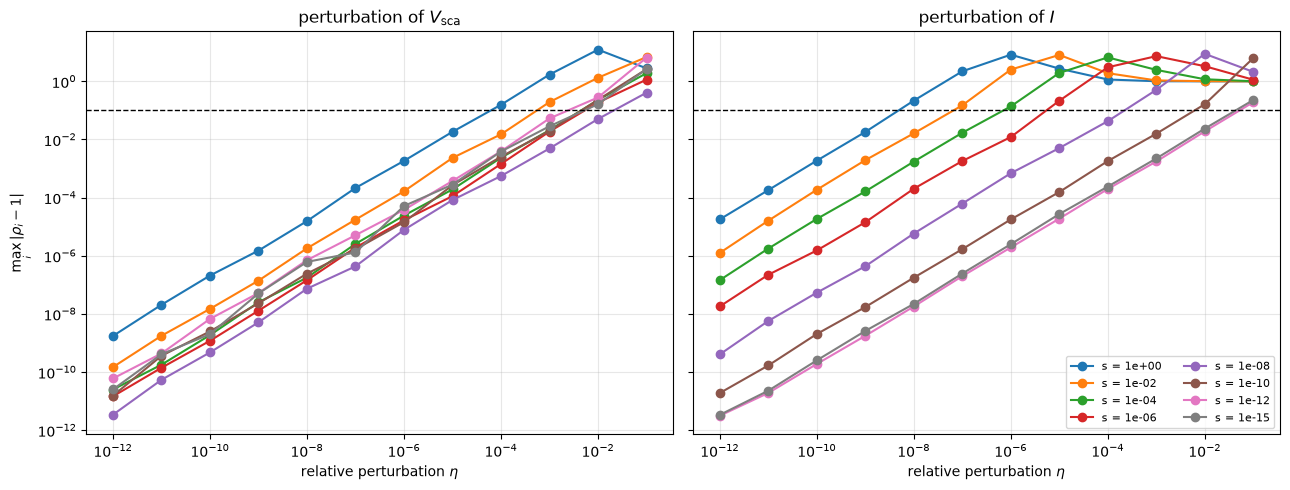

In [4]:
s_grid = np.array([1.0, 1e-2, 1e-4, 1e-6, 1e-8, 1e-10, 1e-12, 1e-15])
eta_grid = np.logspace(-12, -1, 12)
n_trials = 5

errV = np.zeros((len(s_grid), len(eta_grid)))
errI = np.zeros_like(errV)
for i_s, s in enumerate(s_grid):
    Zs = surface_impedance(s)
    I0, V0 = structure(np.ones(Ndes), Zs)
    for i_e, eta in enumerate(eta_grid):
        eV = [np.max(np.abs(complex_density(perturb(V0, eta), Zs) - 1)) for _ in range(n_trials)]
        eI = [np.max(np.abs(complex_density(-Z0 @ perturb(I0, eta), Zs) - 1)) for _ in range(n_trials)]
        errV[i_s, i_e], errI[i_s, i_e] = np.median(eV), np.median(eI)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, err, title in zip(axes, [errV, errI], [r'perturbation of $V_\mathrm{sca}$', r'perturbation of $I$']):
    for i_s, s in enumerate(s_grid):
        ax.loglog(eta_grid, err[i_s], 'o-', label=f's = {s:.0e}')
    ax.axhline(0.1, color='k', ls='--', lw=1)
    ax.set_xlabel(r'relative perturbation $\eta$'); ax.set_title(title)
    ax.grid(True, which='both', alpha=0.3)
axes[0].set_ylabel(r'$\max_i|\rho_i - 1|$')
axes[1].legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

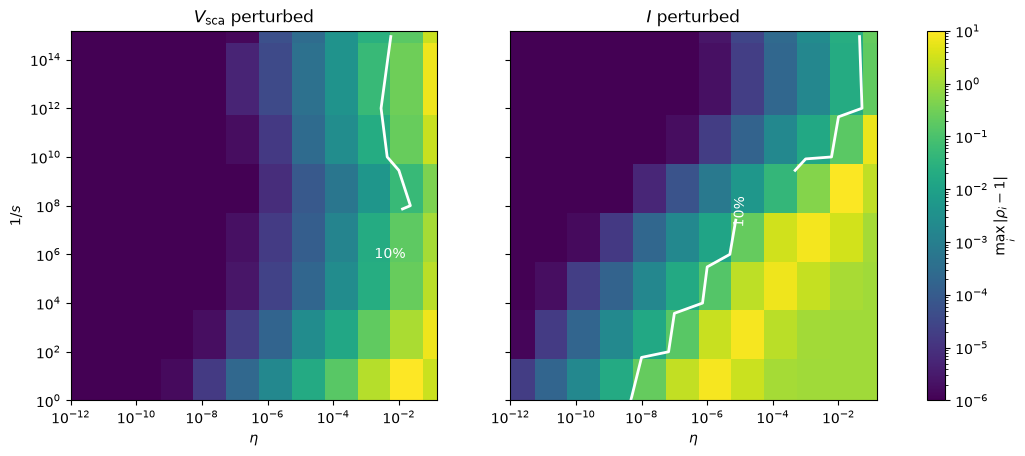

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, err, title in zip(axes, [errV, errI], [r'$V_\mathrm{sca}$ perturbed', r'$I$ perturbed']):
    im = ax.pcolormesh(eta_grid, 1 / s_grid, err, shading='auto', norm=LogNorm(vmin=1e-6, vmax=10))
    CS = ax.contour(eta_grid, 1 / s_grid, err, levels=[0.1], colors='white', linewidths=2)
    ax.clabel(CS, fmt='10%%')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(r'$\eta$'); ax.set_title(title)
axes[0].set_ylabel(r'$1/s$')
fig.colorbar(im, ax=axes, label=r'$\max_i|\rho_i - 1|$')
plt.show()

## 3. Support recovery of a known binary structure

A contiguous block of basis functions (in the whitened basis) is removed, the physical problem is solved for this
$\rho^\mathrm{true} \in \{0,1\}^N$, and $V_\mathrm{sca}$ is perturbed. Because the structure is defined in the same basis as the fits,
the unperturbed solution is recovered exactly ($\rho_i = Z_\mathrm{s} I_i/(V+V_\mathrm{sca})_i$ is $1$ on material and $0$ off it).
Groups are contiguous blocks aligned with the removed block.

In [6]:
keep = np.ones(Ndes, dtype=bool)
keep[Ndes // 3: Ndes // 3 + Ndes // 5] = False
rho_true = keep.astype(float)
print(f"known support: {keep.sum()} / {Ndes}")

def make_groups(gsize):
    edges = [0, Ndes // 3, Ndes // 3 + Ndes // 5, Ndes]
    groups = []
    for a, c in zip(edges[:-1], edges[1:]):
        groups += list(np.array_split(np.arange(a, c), max(1, int(round((c - a) / gsize)))))
    return groups

group_sizes = [1, 4, 16]
keys = [(m, g) for m in ['density', 'current'] for g in group_sizes] + [('branch', 1)]
acc = {k: np.zeros((len(s_grid), len(eta_grid))) for k in keys}

for i_s, s in enumerate(s_grid):
    Zs = surface_impedance(s)
    _, Vb = structure(rho_true, Zs)
    for i_e, eta in enumerate(eta_grid):
        rec = {k: [] for k in keys}
        for _ in range(n_trials):
            Vp = perturb(Vb, eta)
            for g in group_sizes:
                grp = None if g == 1 else make_groups(g)
                rec[('density', g)].append(np.mean((fit_density(Vp, Zs, grp) > 0.5) == keep))
                rec[('current', g)].append(np.mean((fit_current(Vp, Zs, grp) > 0.5) == keep))
            rec[('branch', 1)].append(np.mean(branch_test(Vp, Zs) == keep))
        for k in keys:
            acc[k][i_s, i_e] = np.median(rec[k])
print("done")

known support: 156 / 195


done


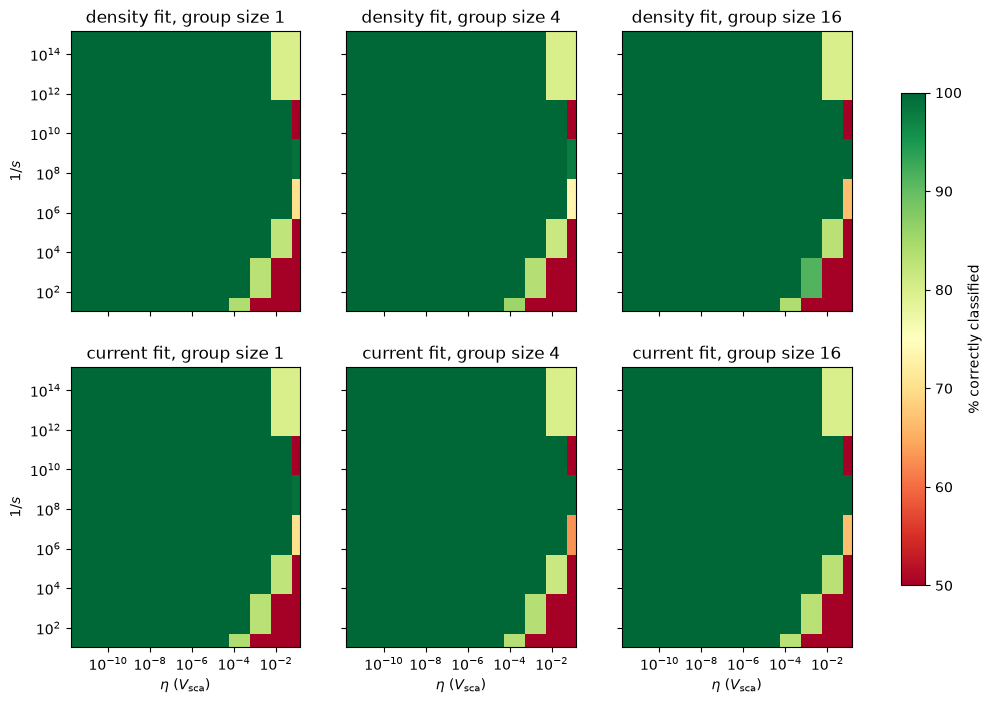

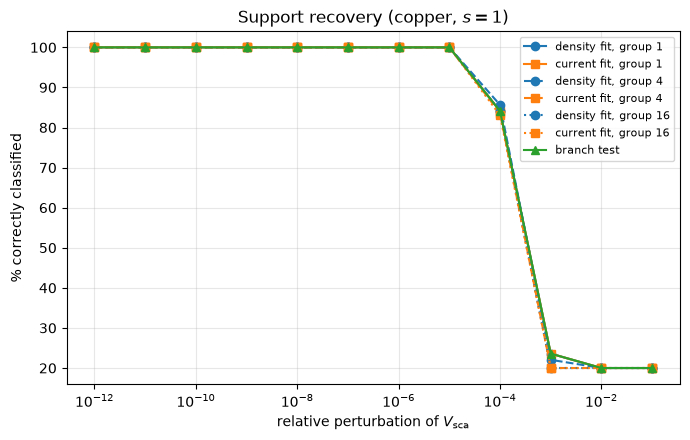

 density g= 1: copper accuracy at eta = 1e-12, 1e-6, 1e-3: 100.0%, 100.0%, 23.6%
 density g= 4: copper accuracy at eta = 1e-12, 1e-6, 1e-3: 100.0%, 100.0%, 22.1%
 density g=16: copper accuracy at eta = 1e-12, 1e-6, 1e-3: 100.0%, 100.0%, 20.0%
 current g= 1: copper accuracy at eta = 1e-12, 1e-6, 1e-3: 100.0%, 100.0%, 23.6%
 current g= 4: copper accuracy at eta = 1e-12, 1e-6, 1e-3: 100.0%, 100.0%, 20.0%
 current g=16: copper accuracy at eta = 1e-12, 1e-6, 1e-3: 100.0%, 100.0%, 20.0%
  branch g= 1: copper accuracy at eta = 1e-12, 1e-6, 1e-3: 100.0%, 100.0%, 23.6%


In [7]:
fig, axes = plt.subplots(2, len(group_sizes), figsize=(4.2 * len(group_sizes), 8), sharex=True, sharey=True)
for j, g in enumerate(group_sizes):
    for i, m in enumerate(['density', 'current']):
        ax = axes[i, j]
        im = ax.pcolormesh(eta_grid, 1 / s_grid, acc[(m, g)] * 100, shading='auto', vmin=50, vmax=100, cmap='RdYlGn')
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_title(f'{m} fit, group size {g}')
        if i == 1: ax.set_xlabel(r'$\eta$ ($V_\mathrm{sca}$)')
        if j == 0: ax.set_ylabel(r'$1/s$')
fig.colorbar(im, ax=axes, label='% correctly classified', shrink=0.8)
plt.show()

i_s1 = 0
fig, ax = plt.subplots(figsize=(7, 4.5))
for g, ls in zip(group_sizes, ['-', '--', ':']):
    ax.semilogx(eta_grid, acc[('density', g)][i_s1] * 100, 'o' + ls, color='C0', label=f'density fit, group {g}')
    ax.semilogx(eta_grid, acc[('current', g)][i_s1] * 100, 's' + ls, color='C1', label=f'current fit, group {g}')
ax.semilogx(eta_grid, acc[('branch', 1)][i_s1] * 100, '^-', color='C2', label='branch test')
ax.set_xlabel(r'relative perturbation of $V_\mathrm{sca}$'); ax.set_ylabel('% correctly classified')
ax.set_title('Support recovery (copper, $s=1$)')
ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()

for k in keys:
    print(f"{k[0]:>8} g={k[1]:>2}: copper accuracy at eta = 1e-12, 1e-6, 1e-3: "
          + ", ".join(f"{acc[k][i_s1, np.argmin(abs(eta_grid - e))] * 100:.1f}%" for e in [1e-12, 1e-6, 1e-3]))

## 4. Fits at the dual solution

The global bound of `VscatBound.ipynb` (real and reactive power conservation, copper) is solved and the fits are applied to
$x^\star = V^\star_\mathrm{sca}$. The relative distance $\|x^\star - V_\mathrm{sca}^\mathrm{full}\|/\|V_\mathrm{sca}^\mathrm{full}\|$ to the
full-plate solution places the dual solution on the $\eta$ axis of Section 2.

dual bound 1.012093e+01 W, full plate 1.010821e+01 W
||x* - Vsca_full|| / ||Vsca_full|| = 9.518e-01
kappa_V(copper) * eta* = 6.879e+01  (predicted relative error of the denominator)
 density fit: mean density 0.024, realized 9.512e-04 W
 current fit: mean density 0.024, realized 9.512e-04 W
 branch test: mean density 0.010, realized 2.455e-11 W


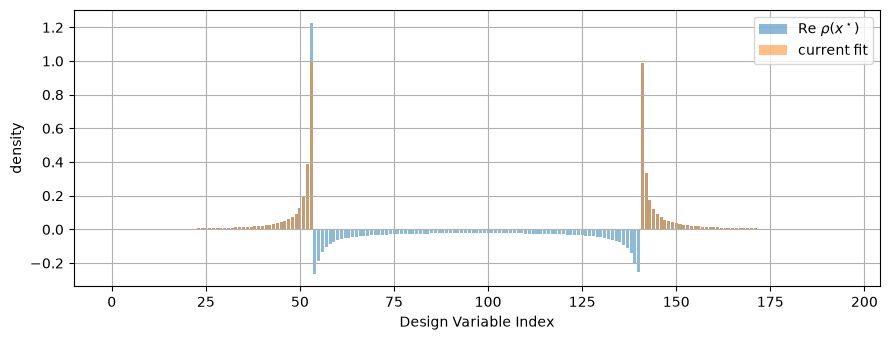

In [8]:
from dolphindes.cvxopt import DenseSharedProjQCQP, OptimizationHyperparameters

Zs = Zs_Cu
WH = W.conj().T
Obj = -0.5 * Msym(WH @ R0 @ W)
A1 = np.eye(Ndes) + np.conj(Zs) * WH
s1 = -0.5 * Vinc
Plist = [sp.diags(np.conj(q) * np.ones(Ndes, dtype=complex)) for q in [1, -1j]]

QCQP = DenseSharedProjQCQP(Obj, np.zeros(Ndes, dtype=complex), 0.0, A1, s1, Plist, A2=W, verbose=0)
opt_params = OptimizationHyperparameters(opttol=1e-6, gradConverge=True, min_inner_iter=10, max_restart=10,
                                         penalty_ratio=1e-2, penalty_reduction=0.1, break_iter_period=5, verbose=0)
QCQP.solve_current_dual_problem(method='newton', init_lags=np.array([1.0, 0.0]), opt_params=opt_params)
xs = QCQP.current_xstar

def realized(rho):
    I, _ = structure(rho, Zs)
    return 0.5 * np.real(I.conj() @ R0 @ I)

eta_star = np.linalg.norm(xs - Vfull) / np.linalg.norm(Vfull)
print(f"dual bound {QCQP.current_dual:.6e} W, full plate {realized(np.ones(Ndes)):.6e} W")
print(f"||x* - Vsca_full|| / ||Vsca_full|| = {eta_star:.3e}")
print(f"kappa_V(copper) * eta* = {kV[0] * eta_star:.3e}  (predicted relative error of the denominator)")
for name, rho in [('density fit', fit_density(xs, Zs)), ('current fit', fit_current(xs, Zs)),
                  ('branch test', branch_test(xs, Zs).astype(float))]:
    print(f"{name:>12}: mean density {rho.mean():.3f}, realized {realized(rho):.3e} W")

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(np.arange(Ndes), np.real(complex_density(xs, Zs)), alpha=0.5, label=r'Re $\rho(x^\star)$')
ax.bar(np.arange(Ndes), fit_current(xs, Zs), alpha=0.5, label='current fit')
ax.set_xlabel('Design Variable Index'); ax.set_ylabel('density'); ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

## Observations

1. **Measured vs. operator amplification.** On the full plate at copper, $\kappa_V \approx 72$, whereas $\|Z_0\|_2/|Z_\mathrm{s}| \approx 10^6$.
   The full-plate $V_\mathrm{sca}$ is dominated by modes that $Z_0$ does not amplify strongly, so the worst-case operator bound overestimates the
   amplification seen by the actual solution by four orders of magnitude.
2. **The $V_\mathrm{sca}$ basis tolerates much more error than the $I$ basis.** The 10% density-error threshold at copper is reached at
   $\eta \approx 10^{-4}$ for a perturbation of $V_\mathrm{sca}$, but already at $\eta \approx 10^{-8}$ for the same relative perturbation of $I$
   (Section 2). An error in $I$ enters $V_\mathrm{sca} = -Z_0 I$ through the large operator $Z_0$, while an error in $V_\mathrm{sca}$ enters $I = -WV_\mathrm{sca}$
   through $W = Z_0^{-1}$, which is small in exactly the directions where $Z_0$ is large. As the conductivity is reduced the gap closes at $1/s = 10^{10}$ and reverses beyond it.
3. **Fitting variants.** As in the current basis, the pointwise current fit, the density fit and the branch test give the same support
   (one density per DOF: $\operatorname{Re}(b_i^*I_i)/|b_i|^2 = \operatorname{Re}\rho_i$). Group-wise fitting does not widen the usable range;
   at copper all variants classify perfectly up to $\eta = 10^{-6}$ and collapse by $\eta = 10^{-3}$ (Section 3).
4. **The dual solution is far outside the usable range.** For the global bound $\|x^\star - V_\mathrm{sca}^\mathrm{full}\|/\|V_\mathrm{sca}^\mathrm{full}\| \approx 0.95$,
   so $x^\star$ is not a small perturbation of a realizable solution, and no fit recovers a useful structure (realized power $\sim 10^{-3}$ W against a
   bound of $10.1$ W). Better conditioning in the $V_\mathrm{sca}$ basis helps only once the dual solution is close to realizable
   (e.g. after enough local constraints); it does not fix the non-physical global optimum.